## 01 — Fitness EDA

### Data loading & preparation 

In [135]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

fitness_df = pd.read_csv(r'..\data\raw\gym_members_exercise_tracking.csv')

### Initial data review

In [136]:
fitness_df.shape  # (973, 15)
fitness_df.columns.to_list()
# ['Age',
#  'Gender',
#  'Weight (kg)',
#  'Height (m)',
#  'Max_BPM',
#  'Avg_BPM',
#  'Resting_BPM',
#  'Session_Duration (hours)',
#  'Calories_Burned',
#  'Workout_Type',
#  'Fat_Percentage',
#  'Water_Intake (liters)',
#  'Workout_Frequency (days/week)',
#  'Experience_Level',
#  'BMI']

fitness_df.info()
fitness_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Data quality 

The dataset is checked for missing values, duplicate observations, incorrect data types, unexpected categorical values, implausible numerical ranges, and logical inconsistencies between related variables.

In [137]:
# dublicates & NaN values 
fitness_df.isna().sum().sum()  # 0 
fitness_df.duplicated().sum()  # 0 


# are all the dtypes correct 
display(fitness_df.dtypes)


# checking categorical columns 
fitness_df.Gender.unique()  # ['Male', 'Female']
fitness_df.Workout_Type.unique()  # ['Yoga', 'HIIT', 'Cardio', 'Strength']


# checking whether all numeric characteristics are correct 
# 1. Age: 
fitness_df.Age.min()  # 18 
fitness_df.Age.max()  # 59 

# 2. Weight: 
fitness_df['Weight (kg)'].min()  # 40
fitness_df['Weight (kg)'].max()  # 129.9 

# 3. Height:
fitness_df['Height (m)'].min()  # 1.5  
fitness_df['Height (m)'].max()  # 2.0 

# 4. BPM (i'll check min/max &  whether there are any incorrect AVG_BPM (> max / < min)):
fitness_df.Max_BPM.max()  # 199 
fitness_df.Resting_BPM.min()  # 50 
((strange_bpm := fitness_df.Max_BPM < fitness_df.Avg_BPM)).sum()  # 23 -> IMO, some avg bpm values can be incorrect

# 5. Workout frequency: 
fitness_df['Workout_Frequency (days/week)'].max()  # 5 < 7 -> no incorrect values 

Age                                int64
Gender                               str
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                         str
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

np.int64(5)

#### Data quality summary

- no missing values were found;
- no duplicate observations were found;
- data types are consistent with the corresponding variables;
- categorical variables contain expected categories only;
- numerical variables were checked for plausible ranges;  
- 23 observations contain `Avg_BPM > Max_BPM`, which is logically inconsistent.

### Exploratory Data Analysis 

In [138]:
# loading preprocessed dataset 
fitness_df = pd.read_csv(r'..\data\processed\fitness_df.csv')
fitness_df.head()

,age,gender,weight_kg,height_cm,max_bpm,avg_bpm,resting_bpm,session_duration_hours,calories_burned,workout_type,fat_percentage,water_intake_liters,workout_frequency_days_week,experience_level,bmi
0,56,Male,88.3,171.0,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,153.0,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,166.0,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,170.0,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,179.0,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


#### Participants’ profile

In [ ]:
# === age === 
print(f'Age distribution:')
fitness_df.age.agg(  
    ['min', 'max', 'median', 'mean', lambda a: a.max() - a.min()]
    ).to_frame().rename(index={'<lambda>': 'spread'}).round(1)  

Age distribution:


,age
min,18.0
max,59.0
median,40.0
mean,38.7
spread,41.0


Gender distibution:


,qty,pct
gender,,
Male,511,52.52
Female,462,47.48


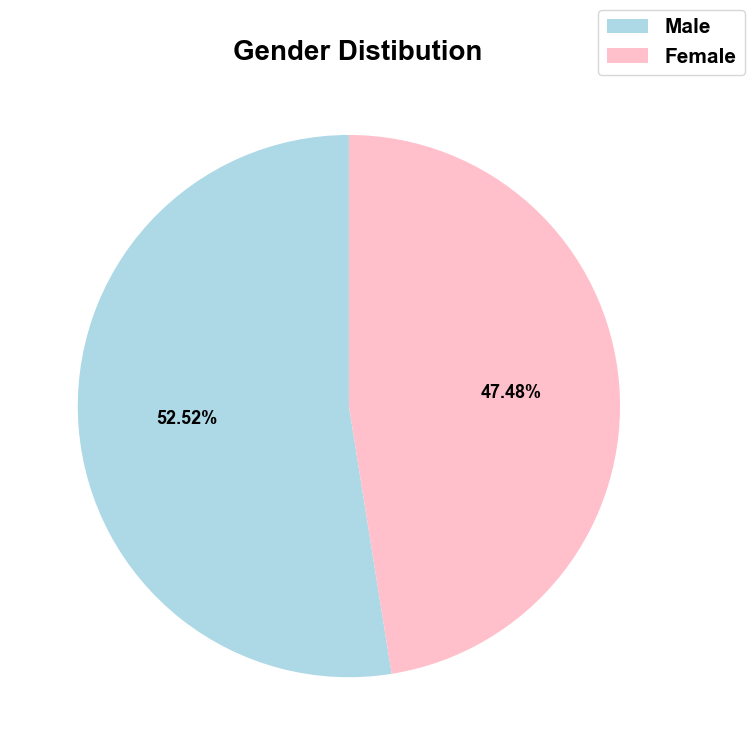

In [ ]:
# === gender ===  
total_qty = fitness_df.gender.count()
vc = fitness_df.gender.value_counts().to_frame()

vc = vc.rename(columns={'count': 'qty'})
vc['pct'] = (vc.qty / total_qty * 100).round(2)

print('Gender distibution:')
display(vc)

plt.figure(figsize=(8, 8))

plt.pie(
    x=vc.pct, 
    colors=['lightblue', 'pink'], 
    startangle=90, 
    textprops={'fontsize': 13, 'fontfamily': 'Arial', 'fontweight': 'semibold'}, 
    autopct='%1.2f%%'
)

plt.legend(
    labels=vc.index, 
    bbox_to_anchor=(1.1, 1.1), 
    fontsize=13, prop={'family': 'Arial', 'size': 15, 'weight': 'semibold'}  
)

plt.suptitle('Gender Distibution', x=.48, y=.9, fontsize=20, fontfamily='Arial', fontweight='semibold')
plt.tight_layout();  

Height distribution:


,height_cm
min,150.0
max,200.0
median,171.0
mean,172.3
spread,50.0


Weight distribution:


,weight_kg
min,40.0
max,129.9
median,70.0
mean,73.9
spread,89.9


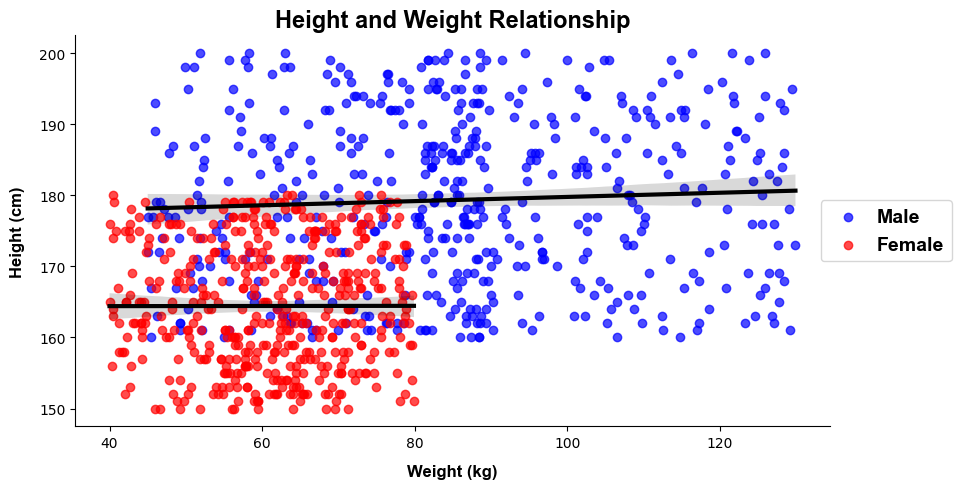

In [ ]:
# === height & weight === 
print(f'Height distribution:')
display(
    fitness_df.height_cm.agg(
        ['min', 'max', 'median', 'mean', lambda a: a.max() - a.min()]
        ).to_frame().rename(index={'<lambda>': 'spread'}).round(1)
    ) 

print(f'Weight distribution:')
display(
    fitness_df.weight_kg.agg(
        ['min', 'max', 'median', 'mean', lambda a: a.max() - a.min()]
        ).to_frame().rename(index={'<lambda>': 'spread'}).round(1)
    )  

# relationship between height & weight
sns.lmplot(
    fitness_df, 
    x='weight_kg', y='height_cm', 
    hue='gender', palette=['blue', 'red'], 
    height=5, aspect=2, 
    line_kws={'color': 'black', 'lw': 3}, 
    scatter_kws={'alpha': .7}, 
    legend=False
    )

plt.xlabel('Weight (kg)', fontfamily='Arial', fontsize=12, labelpad=10, fontweight=600)
plt.ylabel('Height (cm)', fontfamily='Arial', fontsize=12, labelpad=10, fontweight=600)
plt.title('Height and Weight Relationship', fontsize=17, fontweight=600, fontfamily='Arial')

plt.legend(
    prop={'family': 'Arial', 'size': 14, 'weight': 'semibold'}, 
    loc='center right', 
    bbox_to_anchor=(1.175, .5), 
    handletextpad=.5,
    )

plt.tight_layout()

In [200]:
# === bmi === 
print('BMI distribution:')
display(
    fitness_df.bmi.agg(
        ['min', 'max', 'median', 'mean', lambda a: a.max() - a.min()]
        ).to_frame().rename(index={'<lambda>': 'spread'}).round(1)
    ) 

# checking whether all bmi indicators are correct 
bmi_weight_height = fitness_df[['bmi', 'weight_kg', 'height_cm']]
bmi_weight_height['bmi_calc_with_formula'] = bmi_weight_height.weight_kg / (bmi_weight_height.height_cm / 100) ** 2
bmi_weight_height['bmi_diff'] = (bmi_weight_height.bmi - bmi_weight_height.bmi_calc_with_formula).abs()
bmi_weight_height['bmi_problem'] = bmi_weight_height.bmi_diff > .1

print(f'No incorrect results were identified in the BMI indicators in the table -> {bmi_weight_height.bmi_problem.sum()}')

BMI distribution:


,bmi
min,12.3
max,49.8
median,24.2
mean,24.9
spread,37.5


No incorrect results were identified in the BMI indicators in the table -> 0


Fat percentage distribution:


,fat_percentage
min,10.0
max,35.0
median,26.2
mean,25.0
spread,25.0


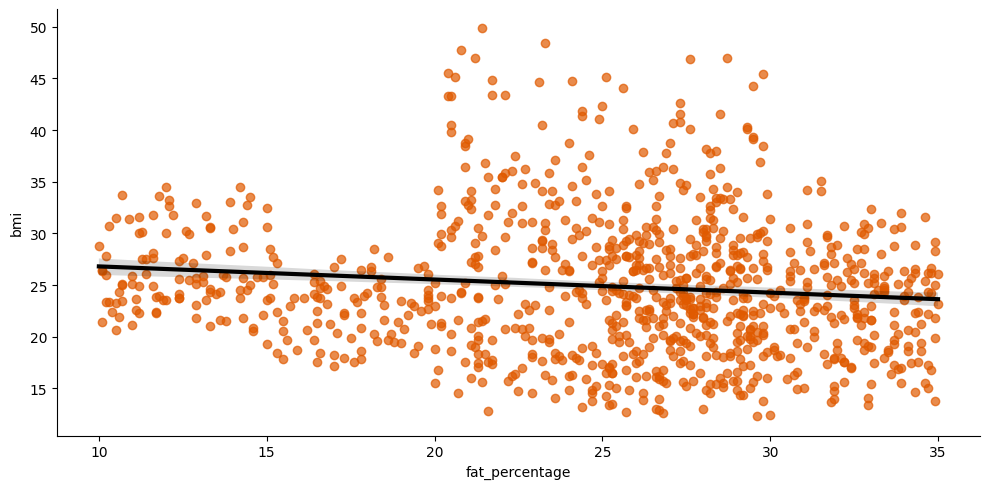

In [209]:
# === fat percentage === 
print('Fat percentage distribution:')
display(
    fitness_df.fat_percentage.agg(
        ['min', 'max', 'median', 'mean', lambda a: a.max() - a.min()]
        ).to_frame().rename(index={'<lambda>': 'spread'}).round(1)
    ) 

# relationship between BMI & fat percentage 
sns.lmplot(
    fitness_df, 
    x='fat_percentage', y='bmi',  
    height=5, aspect=2, 
    line_kws={'color': 'black', 'lw': 3}, 
    scatter_kws={'alpha': .7, 'color': "#E05A00"}, 
    legend=False
    )  # ? strange relationship idk 